In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

### Section 1: Introduction
In a competitive wine industry, businesses are interested in understanding the factors that contribute to high quality wines. The goal of this project is to predict wine quality based on physicochemical properties of wine samples, such as citric acid, density, and other chemical measurements. This is formulated as a classification problem, where each wine is assigned a discrete quality score ranging from 0 (low quality) to 10 (high quality), using the UCI Red Wine Quality dataset. Due to the complexity and overlap between classes, this is a challenging classification task. To address this problem, we apply and compare several machine learning models, including Support Vector Machines, Artificial Neural Networks, and Random Forests.

### Section2: Exploratory Data Analysis

We will begin by loading the dataset into a dataframe and displaying the first 5 entries.

In [51]:
df = pd.read_csv("./Data/winequality-red-1.csv",sep=";|,",engine="python")
df.columns = df.columns.str.replace('"', '').str.strip() 
X = df.drop('quality',axis=1)
y = df['quality']
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


We will now get high level information from the dataset such as the features, null counts, datatypes, and dimension (rows and columns).

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   "fixed acidity            1599 non-null   float64
 1   ""volatile acidity""      1599 non-null   float64
 2   ""citric acid""           1599 non-null   float64
 3   ""residual sugar""        1599 non-null   float64
 4   ""chlorides""             1599 non-null   float64
 5   ""free sulfur dioxide""   1599 non-null   float64
 6   ""total sulfur dioxide""  1599 non-null   float64
 7   ""density""               1599 non-null   float64
 8   ""pH""                    1599 non-null   float64
 9   ""sulphates""             1599 non-null   float64
 10  ""alcohol""               1599 non-null   float64
 11  ""quality"""              1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [49]:
df.isnull().values.any() 

False

There are 1599 entries in the datset with 11 features and 1 target variable of quality. There are no null entries in the dataset.

In [37]:
df.describe()

,"""fixed acidity","""""volatile acidity""""","""""citric acid""""","""""residual sugar""""","""""chlorides""""","""""free sulfur dioxide""""","""""total sulfur dioxide""""","""""density""""","""""pH""""","""""sulphates""""","""""alcohol""""","""""quality"""""""
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


I will check the number of entries of each wine quality.

In [39]:
df["quality"].value_counts() 

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [ ]:
It looks like the classes are unbalanced so we must take this into account.

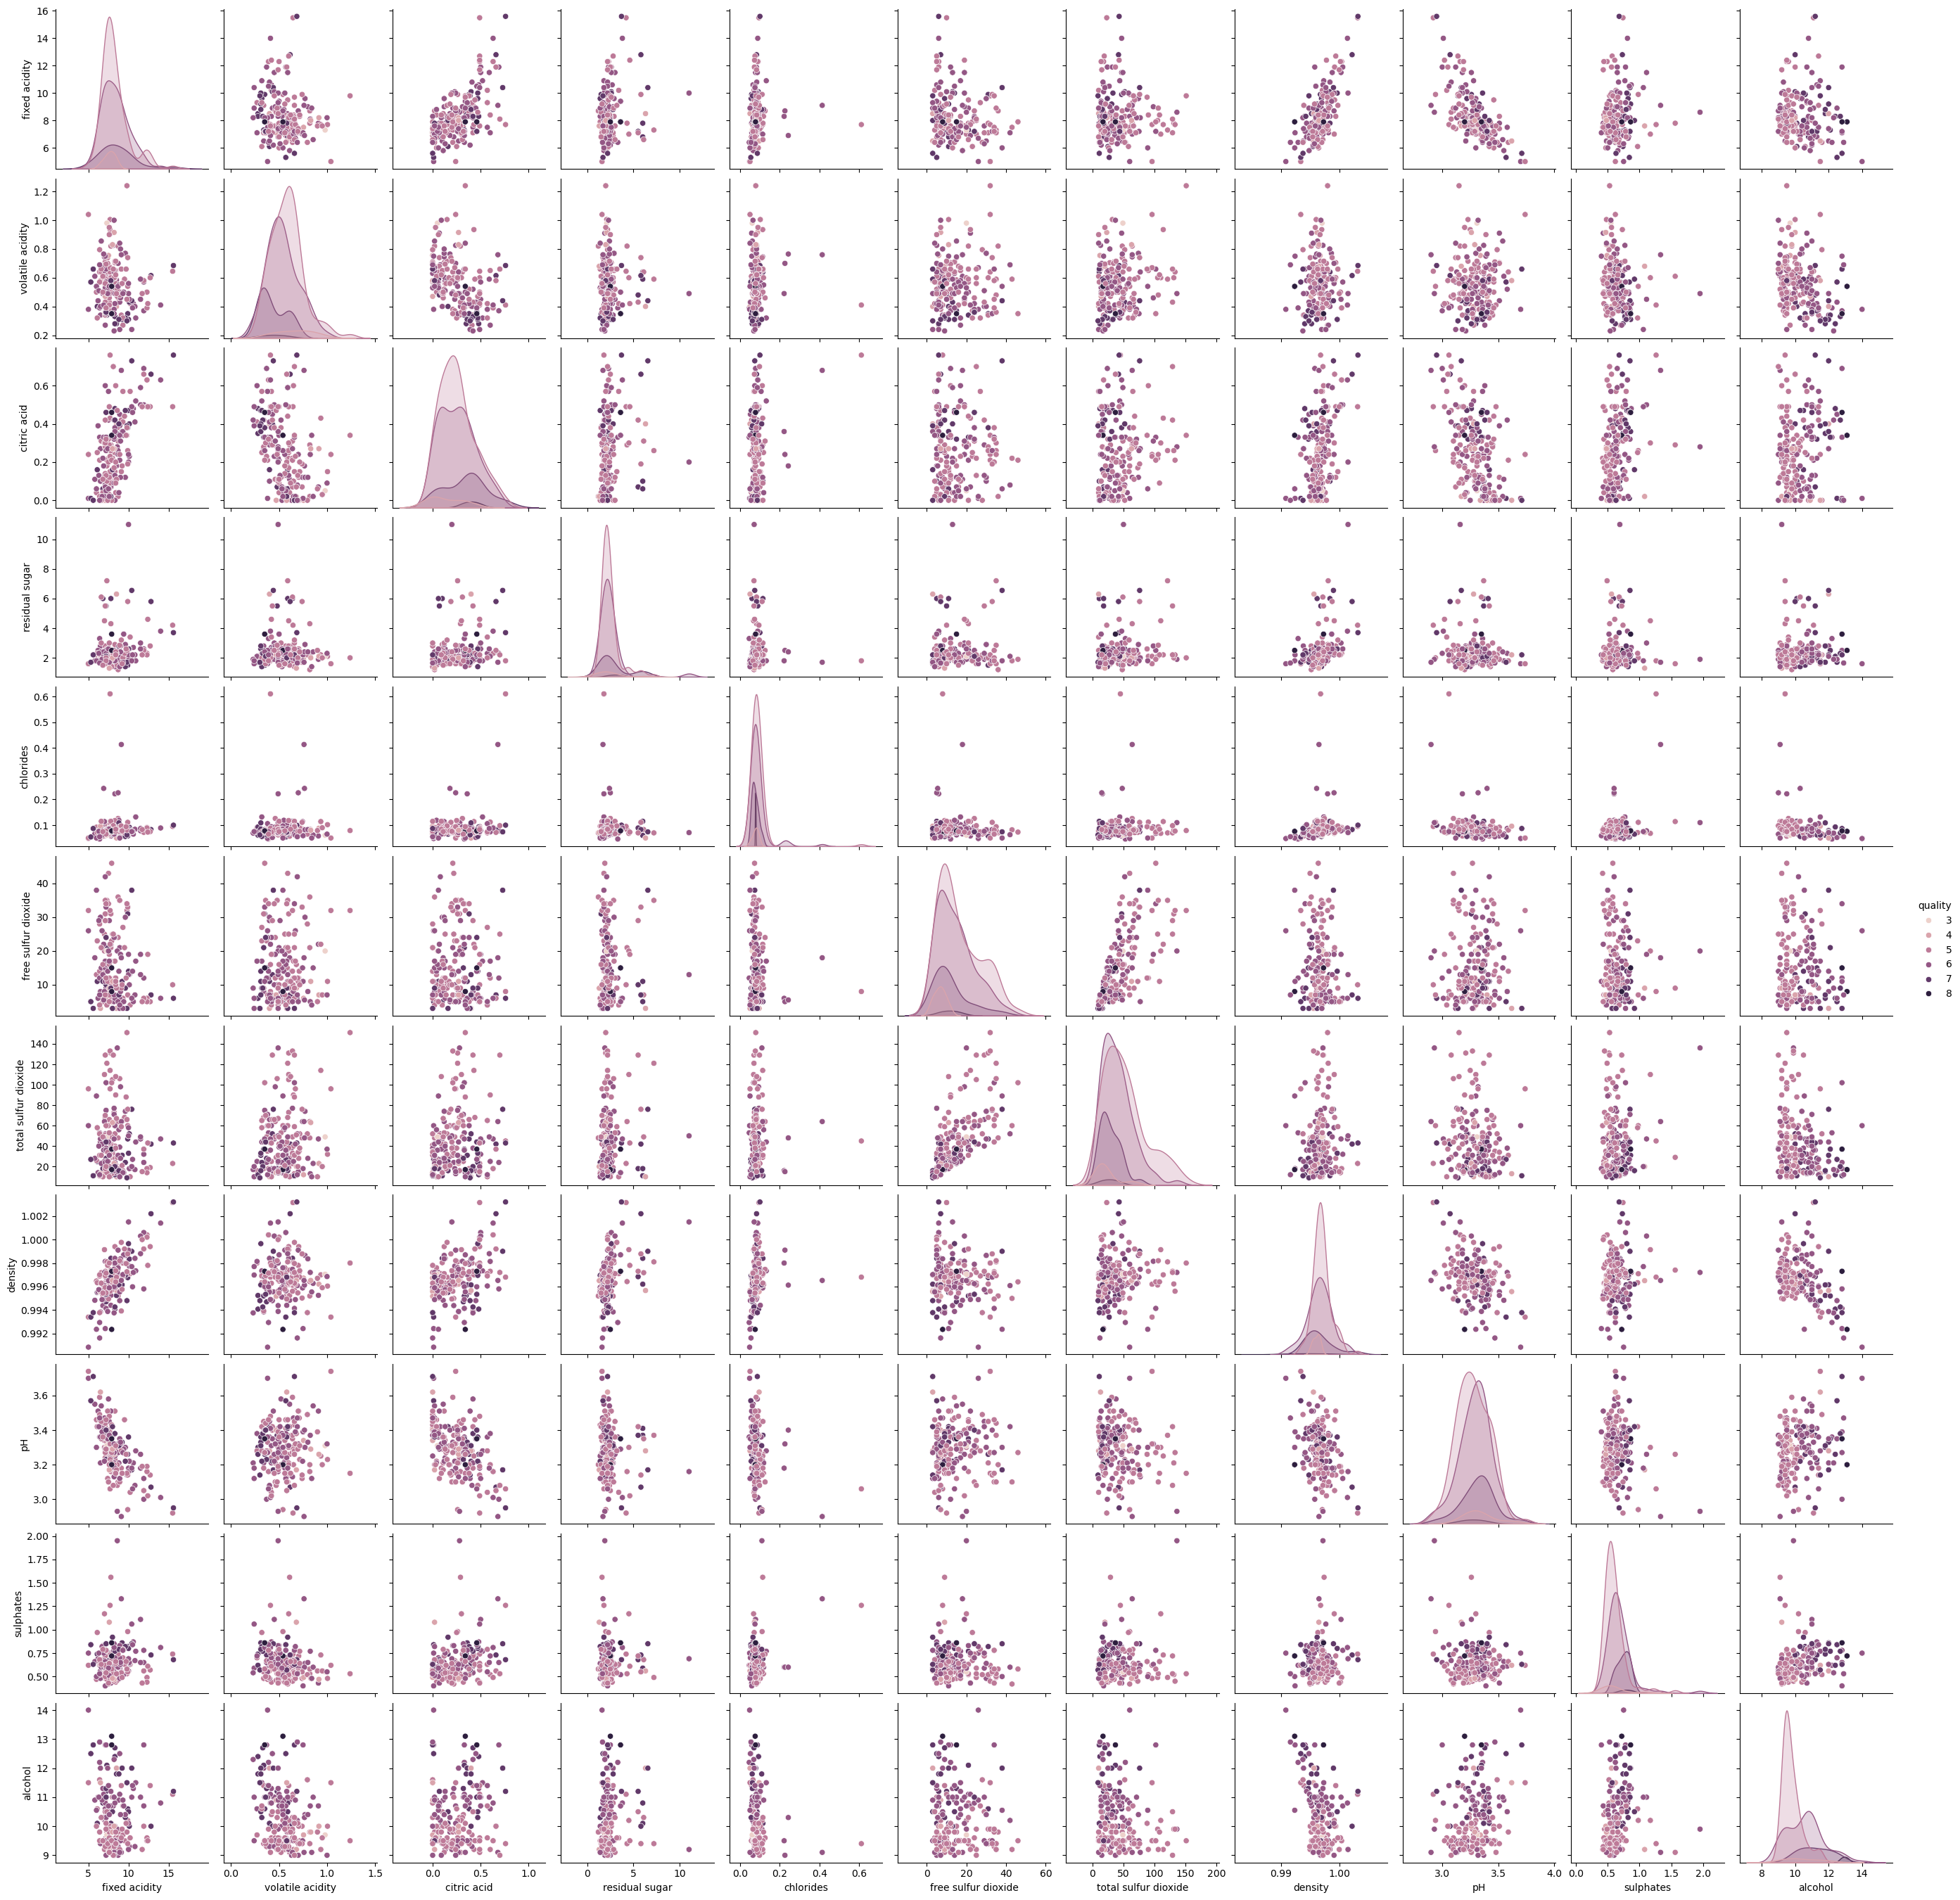

In [61]:
sns.pairplot(df.sample(200), hue="quality") 


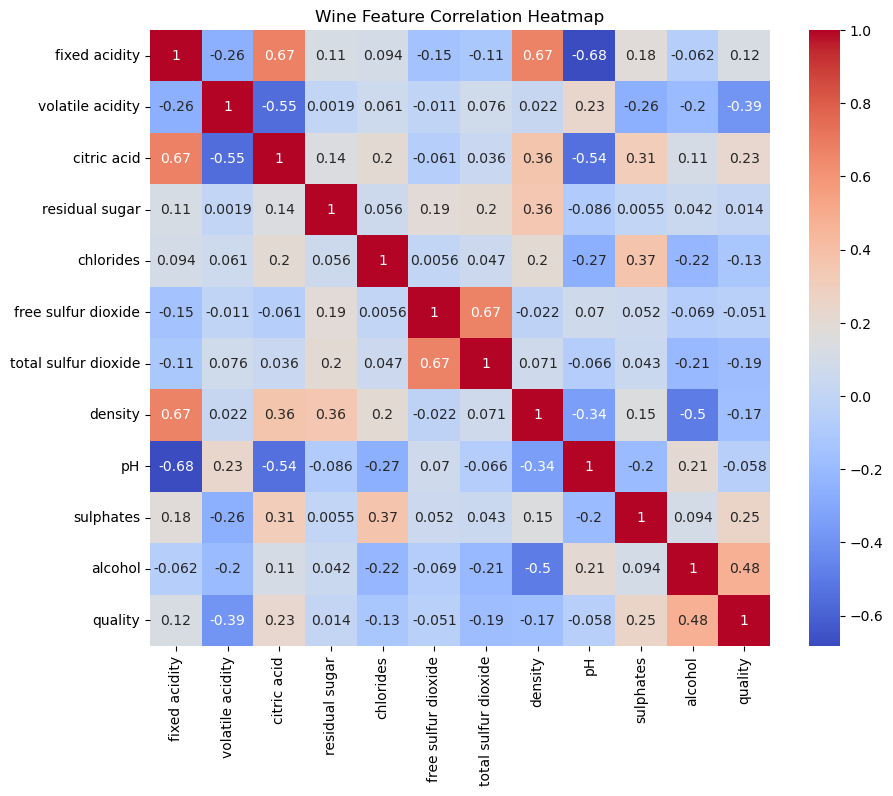

In [60]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)
plt.title("Wine Feature Correlation Heatmap")
plt.show()


From the correlation heatmap it appears that fixed acidity has a moderately strong negative relationship with pH. Furthermore fixed acidity has a moderately strong positve relationship with citric acid. Additionally free sulfur dioxide has a moderately strong positive relationship with total sulfur diaoxide and density has a moderately strong positive relationship with fixed acidity. As for the relationshps between the features and target variable of wine quality, alcohol appears to have a moderate positive correlation with wine quality and volatile acidity appears to have a negative correlation with wine quality with the other features having quite weak correlations with wine quality. This suggests that the majority of relationships between the wine features and target quality is not strongly linear which suggests that more complex models maybe required to accurately capture the underlying patterns. 

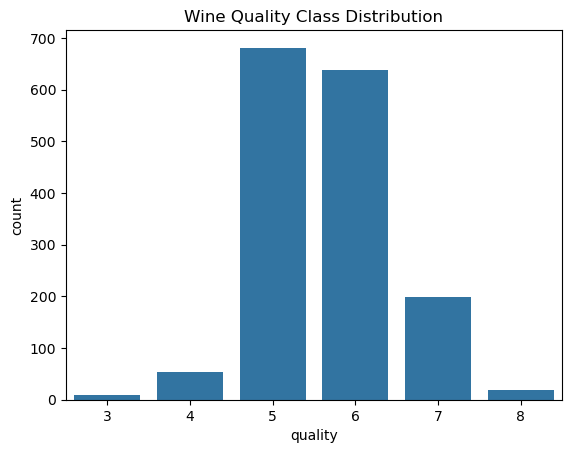

In [63]:
sns.countplot(x="quality", data=df)
plt.title("Wine Quality Class Distribution")
plt.show()

The distribution of the target variable class (wine quality) is imbalanced as the majority of wine samples are concentrated in quality of 5 and 6, and very few samples belong to the classes 3 and 8. 

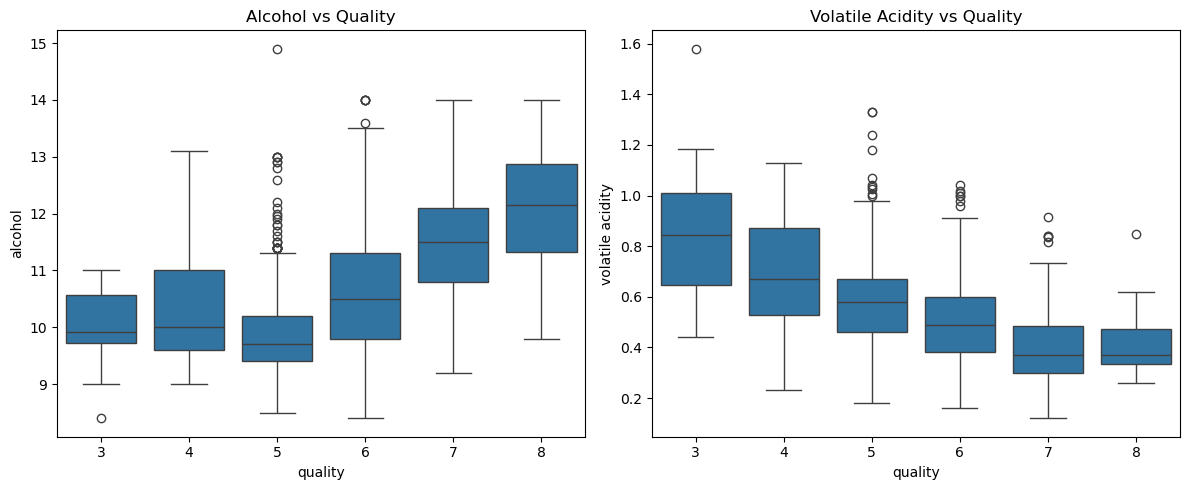

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(ax=axes[0], x="quality", y="alcohol", data=df)
axes[0].set_title("Alcohol vs Quality")

sns.boxplot(ax=axes[1], x="quality", y="volatile acidity", data=df)
axes[1].set_title("Volatile Acidity vs Quality")

plt.tight_layout()
plt.show()

From the correlation heatmap, alcohol and volatile acidity showed the strongest relationships with wine quality. To further examine these relationships, we analyze their distributions across different quality levels using boxplots. The results show that alcohol has a positive relationship with quality, while volatile acidity has a negative relationship with quality.

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #80/20 Split

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Before tuning hyper parameters I will train and predict using a baseline random forest model.

In [74]:
random_forest_baseline = RandomForestClassifier(random_state=42)

random_forest_baseline.fit(X_train, y_train)
y_pred_baseline = random_forest_baseline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Baseline Weighted F1:", f1_score(y_test, y_pred_baseline, average="weighted"))
print(classification_report(y_test, y_pred_baseline))

Baseline Accuracy: 0.659375
Baseline Weighted F1: 0.6437864795480438
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.74      0.72       130
           6       0.63      0.70      0.66       132
           7       0.64      0.55      0.59        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320



/Users/shangwenyota/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/shangwenyota/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/shangwenyota/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Now will perfrom grid search to find the best hyperparameters for the Random Forest Model.

In [ ]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 250],
    "max_depth": [None, 5, 10, 20, 25],
    "min_samples_split": [2, 5, 8],
    "min_samples_leaf": [1, 2, 3],
    "class_weight": [None, "balanced"]
}
rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=rf_cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("Best Cross-Validation F1 Score:")
print(grid_rf.best_score_)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits


In [85]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Tuned Random Forest Precision:", precision_score(y_test, y_pred_rf, average="weighted", zero_division=0))
print("Tuned Random Forest Recall:", recall_score(y_test, y_pred_rf, average="weighted", zero_division=0))
print("Tuned Random Forest F1:", f1_score(y_test, y_pred_rf, average="weighted", zero_division=0))

print(classification_report(y_test, y_pred_rf, zero_division=0))
print(confusion_matrix(y_test, y_pred_rf))

Tuned Random Forest Accuracy: 0.66875
Tuned Random Forest Precision: 0.6374695809230995
Tuned Random Forest Recall: 0.66875
Tuned Random Forest F1: 0.6504816925263022
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.76      0.74       130
           6       0.64      0.71      0.67       132
           7       0.66      0.50      0.57        42
           8       0.00      0.00      0.00         5

    accuracy                           0.67       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.64      0.67      0.65       320

[[ 0  0  1  0  0  0]
 [ 0  0  7  3  0  0]
 [ 0  0 99 31  0  0]
 [ 0  0 32 94  6  0]
 [ 0  0  0 20 21  1]
 [ 0  0  0  0  5  0]]


### Section 3: Methods
In this project we used three different classification models (Support Vector Machines, Artificial Neural Networks, and Random Forest) to predict the quality of wine. Before training the different we did EDA and preprocessing. We split the dataset using an 80/20 split. Since Support Vector Machines and Artificial Neural Networks are sensitive to the scale of input features, we applied standardization to the dataset using scikit learn feature scaler.

The Random Forest model is an ensemble learning method that consists of multiple decision trees. It leverages bootstrap sampling of the training data through a technique known as bagging, where each tree is trained on a slightly different subset of the data. Additionally, Random Forest introduces randomness by selecting a random subset of features at each split when constructing the trees. By combining many decision trees, each trained on different data samples and feature subsets, the model reduces overfitting and improves generalization. The final prediction is obtained by aggregating the predictions of the individual trees, typically through majority voting in classification tasks.

TODO: Add SVM, ANN

For improving the model performance we tuned hyperparameters. For Random Forest, we tuned the number of trees and max depths are tuned. For SVM.... for Neural Network.... (num hidden layers and nodes?). 

### Section 4: Results and Analysis

### Section 5: Conclusions

### Section 6: Appendix